In [2]:
import pandas as pd

df = pd.read_csv('C:/PROJECTS/zomato.csv', encoding = 'latin-1', usecols = range(17))

print("rows:", len(df))
print("columns:", len(df.columns))

print(df.columns.tolist())

C:\Users\pavit\AppData\Local\Temp\ipykernel_26052\627750912.py:3: DtypeWarning: Columns (0: votes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:/PROJECTS/zomato.csv', encoding = 'latin-1', usecols = range(17))


rows: 56250
columns: 17
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [3]:
import pandas as pd

df = pd.read_csv('C:/PROJECTS/zomato.csv',encoding = 'latin-1', usecols=range(
                 17),low_memory=False)
# STEP 1: Keep only useful columns
df = df[['name', 'location', 'rest_type', 'cuisines',
         'approx_cost(for two people)', 'online_order',
         'book_table', 'rate', 'votes', 'listed_in(type)']]

# STEP 2: Rename columns to simple names
df.columns = ['name', 'location', 'rest_type', 'cuisines',
              'cost', 'online_order', 'book_table',
              'rate', 'votes', 'type']

# STEP 3: Fix the rate column — remove "/5"
df['rate'] = df['rate'].astype(str).str.replace('/5', '').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# STEP 4: Fix cost column — remove commas
df['cost'] = df['cost'].astype(str).str.replace(',', '').str.strip()
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

# STEP 5: Remove duplicates
df = df.drop_duplicates(subset=['name', 'location'])

# STEP 6: Drop rows with no rating or cost
df = df.dropna(subset=['rate', 'cost'])

# STEP 7: Save clean file
df.to_csv('C:/PROJECTS/zomato_clean.csv', index=False)

print("✅ Cleaning done!")
print("Clean rows:", len(df))
print("Columns:", df.columns.tolist())
print(df.head(3))

✅ Cleaning done!
Clean rows: 9005
Columns: ['name', 'location', 'rest_type', 'cuisines', 'cost', 'online_order', 'book_table', 'rate', 'votes', 'type']
              name      location            rest_type  \
0            Jalsa  Banashankari        Casual Dining   
1   Spice Elephant  Banashankari        Casual Dining   
2  San Churro Cafe  Banashankari  Cafe, Casual Dining   

                         cuisines   cost online_order book_table  rate votes  \
0  North Indian, Mughlai, Chinese  800.0          Yes        Yes   4.1   775   
1     Chinese, North Indian, Thai  800.0          Yes         No   4.1   787   
2          Cafe, Mexican, Italian  800.0          Yes         No   3.8   918   

     type  
0  Buffet  
1  Buffet  
2  Buffet  


✅ Data ready! Rows: 9005


C:\Users\pavit\AppData\Local\Temp\ipykernel_4992\2583804962.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='Oranges_r')


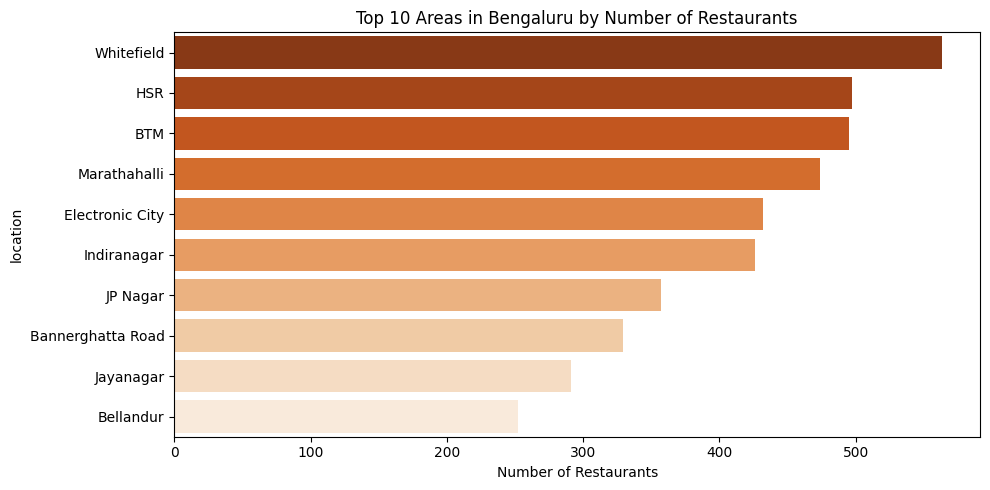

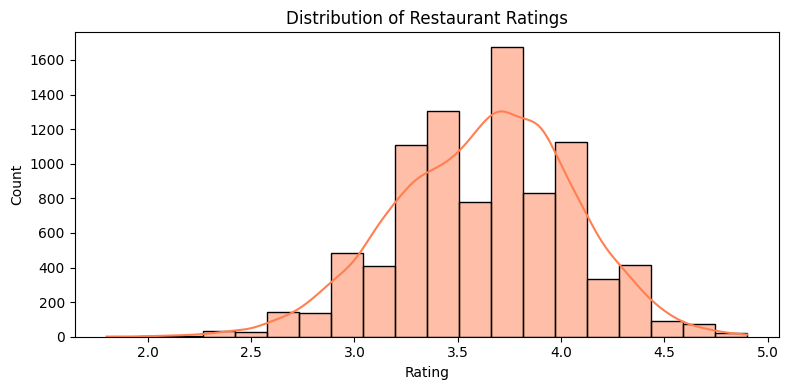

C:\Users\pavit\AppData\Local\Temp\ipykernel_4992\2583804962.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order', y='rate', data=df, palette='Set2')


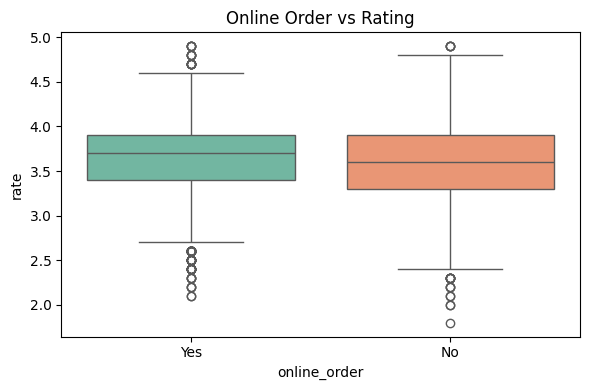

✅ All 3 charts saved to C:/PROJECTS/


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── LOAD ──────────────────────────────────────────
df = pd.read_csv('C:/PROJECTS/zomato.csv',
                 encoding='latin-1',
                 usecols=range(17),
                 low_memory=False)

# ── CLEAN ─────────────────────────────────────────
df = df[['name', 'location', 'rest_type', 'cuisines',
         'approx_cost(for two people)', 'online_order',
         'book_table', 'rate', 'votes', 'listed_in(type)']]

df.columns = ['name', 'location', 'rest_type', 'cuisines',
              'cost', 'online_order', 'book_table',
              'rate', 'votes', 'type']

df['rate'] = df['rate'].astype(str).str.replace('/5','').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['cost'] = df['cost'].astype(str).str.replace(',','').str.strip()
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')
df = df.drop_duplicates(subset=['name','location'])
df = df.dropna(subset=['rate','cost'])

print("✅ Data ready! Rows:", len(df))

# ── CHART 1 — Top 10 locations ────────────────────
plt.figure(figsize=(10, 5))
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='Oranges_r')
plt.title('Top 10 Areas in Bengaluru by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('C:/PROJECTS/top_locations.png', dpi=150)
plt.show()

# ── CHART 2 — Rating distribution ─────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df['rate'], bins=20, color='coral', kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.tight_layout()
plt.savefig('C:/PROJECTS/rating_distribution.png', dpi=150)
plt.show()

# ── CHART 3 — Online order vs Rating ──────────────
plt.figure(figsize=(6, 4))
sns.boxplot(x='online_order', y='rate', data=df, palette='Set2')
plt.title('Online Order vs Rating')
plt.tight_layout()
plt.savefig('C:/PROJECTS/online_vs_rating.png', dpi=150)
plt.show()

print("✅ All 3 charts saved to C:/PROJECTS/")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# ── LOAD ──────────────────────────────────────────
df = pd.read_csv('C:/PROJECTS/zomato.csv',
                 encoding='latin-1',
                 usecols=range(17),
                 low_memory=False)

# ── CLEAN ─────────────────────────────────────────
df = df[['name', 'location', 'rest_type', 'cuisines',
         'approx_cost(for two people)', 'online_order',
         'book_table', 'rate', 'votes', 'listed_in(type)']]

df.columns = ['name', 'location', 'rest_type', 'cuisines',
              'cost', 'online_order', 'book_table',
              'rate', 'votes', 'type']

df['rate'] = df['rate'].astype(str).str.replace('/5','').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['cost'] = df['cost'].astype(str).str.replace(',','').str.strip()
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')
df = df.drop_duplicates(subset=['name','location'])
df = df.dropna(subset=['rate','cost'])
print("✅ Data ready! Rows:", len(df))


# ── CHARTS ────────────────────────────────────────
plt.figure(figsize=(10,5))
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='Oranges_r')
plt.title('Top 10 Areas in Bengaluru by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('C:/PROJECTS/top_locations.png', dpi=150)
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['rate'], bins=20, color='coral', kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.tight_layout()
plt.savefig('C:/PROJECTS/rating_distribution.png', dpi=150)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='online_order', y='rate', data=df, palette='Set2')
plt.title('Online Order vs Rating')
plt.tight_layout()
plt.savefig('C:/PROJECTS/online_vs_rating.png', dpi=150)
plt.show()
print("✅ 3 charts saved!")

# Load clean data into a SQL database
conn = sqlite3.connect('C:/PROJECTS/zomato.db')
df.to_sql('restaurants', conn, if_exists='replace', index=False)
print("✅ Data loaded into SQL!")

# Query 1 — Top 10 locations by restaurant count
q1 = pd.read_sql_query("""
    SELECT location,
           COUNT(*) AS total_restaurants
    FROM restaurants
    GROUP BY location
    ORDER BY total_restaurants DESC
    LIMIT 10
""", conn)
print("\n📍 Top 10 Locations:")
print(q1)

# Query 2 — Average rating by restaurant type
q2 = pd.read_sql_query("""
    SELECT rest_type,
           COUNT(*) AS count,
           ROUND(AVG(rate), 2) AS avg_rating
    FROM restaurants
    WHERE rest_type IS NOT NULL
    GROUP BY rest_type
    ORDER BY avg_rating DESC
    LIMIT 10
""", conn)
print("\n🍽️ Best Rated Restaurant Types:")
print(q2)

# Query 3 — Does cost affect rating?
q3 = pd.read_sql_query("""
    SELECT
      CASE
        WHEN cost < 300  THEN 'Budget (under 300)'
        WHEN cost < 600  THEN 'Mid-range (300-600)'
        WHEN cost < 1000 THEN 'Premium (600-1000)'
        ELSE 'Luxury (1000+)'
      END AS price_band,
      COUNT(*) AS restaurants,
      ROUND(AVG(rate), 2) AS avg_rating
    FROM restaurants
    WHERE rate IS NOT NULL
    GROUP BY price_band
    ORDER BY avg_rating DESC
""", conn)
print("\n💰 Cost vs Rating:")
print(q3)

# Query 4 — Online delivery breakdown
q4 = pd.read_sql_query("""
    SELECT online_order,
           COUNT(*) AS total,
           ROUND(AVG(rate), 2) AS avg_rating,
           ROUND(AVG(cost), 0) AS avg_cost
    FROM restaurants
    GROUP BY online_order
""", conn)
print("\n🛵 Online Delivery Analysis:")
print(q4)

conn.close()
print("\n✅ All SQL queries done!")

## 🔍 Key Findings from SQL Analysis

### 📍 Location Insights
- Whitefield has the most restaurants (563) — driven by IT workforce density
- Top 5 areas are all major tech/residential hubs in Bengaluru

### 🍽️ Restaurant Type Insights  
- Microbreweries and Pubs have the highest ratings (4.4–4.6)
- Ambience and experience matter more than just food for high ratings

### 💰 Cost vs Rating
- Luxury restaurants (₹1000+) have the highest avg rating of 4.03
- Clear trend: higher spend = better customer satisfaction
- Budget restaurants cluster around 3.55 rating

### 🛵 Online Delivery
- 61% of restaurants offer online delivery
- Delivery restaurants are cheaper (₹492 avg) but rated slightly higher (3.65)
- Best value for money = restaurants with online delivery